# Quantum States, Circuits & Measurement — with NumPy, SciPy, and Qiskit

**Quantum Computing Spring School 2026**
Session 2

Welcome back! In [Session 1](../session-1-python-intro/01_intro_python_for_quantum_computing.ipynb) we built up general Python and scientific-computing fluency: NumPy arrays, `scipy.linalg`, and Matplotlib. Today we spend the first half of this notebook using exactly those tools — nothing new to install, nothing new to learn syntactically — to build the mathematical objects of quantum computing **by hand**: state vectors, unitary matrices, circuits as products of matrices, and measurement as sampling from a probability distribution.

Only once those ideas are solid do we introduce **Qiskit**, IBM's open-source SDK for quantum computing. The payoff of doing it this way round is that Qiskit's objects (`QuantumCircuit`, `Statevector`, `SparsePauliOp`, samplers and estimators) will look like *thin, convenient wrappers* around things you already understand — not like magic.

**A scope note before we start:** everything in this notebook runs on a **classical simulator** — either NumPy directly, or Qiskit's built-in `Statevector`/`Sampler`/`Estimator` primitives and the `qiskit-aer` simulator package. We are not submitting jobs to real quantum hardware in this school; simulators are the right tool for learning the ideas, they give you exact access to amplitudes that a real device never would, and everything here runs comfortably on a laptop for the small circuits (2–4 qubits) we'll use.

**What we'll cover today:**

1. Recap: complex vectors and matrices in NumPy/SciPy
2. Quantum states
3. Quantum evolution via unitaries
4. Quantum circuits (built by hand)
5. Measurement and observables (built by hand)
6. Enter Qiskit: what it is and how it's organised
7. Qiskit fundamentals: `QuantumCircuit`, `Statevector`, `Operator`
8. Measurement in Qiskit: shots and counts
9. Observables in Qiskit: `SparsePauliOp` and the `Estimator`
10. Putting it together — a small capstone exercise

Each section has one or more **Exercises** — attempt them before running the solution cell underneath.

In [1]:
import numpy as np
from scipy.linalg import expm

np.set_printoptions(precision=4, suppress=True)

---

## 1. Recap: complex vectors and matrices in NumPy/SciPy

Quantum mechanics is linear algebra over the complex numbers. Session 1 covered NumPy arrays, matrix multiplication with `@`, and `scipy.linalg.eig` — everything below reuses exactly that, just with complex entries.

### 1.1 State vectors as NumPy arrays

A quantum state is represented by a complex column vector. We'll write it as a 1D NumPy array with `dtype=complex`:

In [2]:
psi = np.array([1, 0], dtype=complex)
phi = np.array([1, 1], dtype=complex) / np.sqrt(2)

print("psi =", psi)
print("phi =", phi)

psi = [1.+0.j 0.+0.j]
phi = [0.7071+0.j 0.7071+0.j]


The **inner product** ⟨ψ|φ⟩ (bra ψ against ket φ) is the conjugate-transpose of `psi` dotted with `phi`. NumPy gives you this directly with `np.vdot`, which conjugates its *first* argument for you:

In [3]:
inner_product = np.vdot(psi, phi)   # <psi|phi>
print("<psi|phi> =", inner_product)

# equivalently, spelled out:
inner_product_manual = psi.conj() @ phi
print("same thing, spelled out:", inner_product_manual)

<psi|phi> = (0.7071067811865475+0j)
same thing, spelled out: (0.7071067811865475+0j)


The **norm** of a state vector, ‖ψ‖ = √⟨ψ|ψ⟩, tells us whether it's a valid quantum state — physical states must have norm 1:

In [4]:
print("norm of psi:", np.linalg.norm(psi))
print("norm of phi:", np.linalg.norm(phi))

norm of psi: 1.0
norm of phi: 0.9999999999999999


### 1.2 Matrices: Hermitian and unitary

Two special classes of complex matrix matter enormously in quantum mechanics:

- **Hermitian**: $A = A^\dagger$ (equal to its own conjugate transpose). Observables are represented by Hermitian matrices.
- **Unitary**: $U U^\dagger = U^\dagger U = I$ (its conjugate transpose is its inverse). Time evolution is represented by unitary matrices.

In NumPy, the conjugate transpose of an array `A` is `A.conj().T`:

In [5]:
Hgate = np.array([[1, 1],
                   [1, -1]], dtype=complex) / np.sqrt(2)

print("Hgate:\n", Hgate)
print("Is Hgate Hermitian?", np.allclose(Hgate, Hgate.conj().T))
print("Is Hgate unitary?  ", np.allclose(Hgate @ Hgate.conj().T, np.eye(2)))

Hgate:
 [[ 0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071+0.j]]
Is Hgate Hermitian? True
Is Hgate unitary?   True


### 1.3 The matrix exponential: `scipy.linalg.expm`

A very common way to *build* a unitary matrix is to exponentiate a Hermitian matrix: if $H$ is Hermitian, then $U = e^{-iH}$ is automatically unitary. This is exactly how continuous-time evolution and parametrised rotation gates are constructed, and it's a one-line call with `scipy.linalg.expm` (the matrix analogue of `np.exp`, which only works elementwise and would be *wrong* here):

In [6]:
X = np.array([[0, 1],
              [1, 0]], dtype=complex)

theta = np.pi / 3
Rx_theta = expm(-1j * theta / 2 * X)

print("Rx(pi/3):\n", Rx_theta)
print("Is it unitary?", np.allclose(Rx_theta @ Rx_theta.conj().T, np.eye(2)))

Rx(pi/3):
 [[0.866+0.j  0.   -0.5j]
 [0.   -0.5j 0.866+0.j ]]
Is it unitary? True


**Exercise:** the Pauli matrices are

$$
X = \begin{pmatrix}0&1\\1&0\end{pmatrix}, \quad
Y = \begin{pmatrix}0&-i\\i&0\end{pmatrix}, \quad
Z = \begin{pmatrix}1&0\\0&-1\end{pmatrix}.
$$

Define all three as NumPy arrays, confirm each is Hermitian, and use `scipy.linalg.expm` to build $R_z(\theta) = e^{-i\theta Z/2}$ for $\theta = \pi/2$. Confirm the result is unitary.

In [7]:
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

for name, M in [("X", X), ("Y", Y), ("Z", Z)]:
    print(name, "Hermitian?", np.allclose(M, M.conj().T))

theta = np.pi / 2
Rz_theta = expm(-1j * theta / 2 * Z)
print("Rz(pi/2):\n", Rz_theta)
print("unitary?", np.allclose(Rz_theta @ Rz_theta.conj().T, np.eye(2)))

X Hermitian? True
Y Hermitian? True
Z Hermitian? True
Rz(pi/2):
 [[0.7071-0.7071j 0.    +0.j    ]
 [0.    +0.j     0.7071+0.7071j]]
unitary? True


---

## 2. Quantum states

**Postulate 1 (states).** The state of an isolated quantum system is a unit vector $|\psi\rangle$ in a complex vector space (a Hilbert space). For a single **qubit**, that space is $\mathbb{C}^2$.

### 2.1 A qubit as a 2D complex vector

We fix the *computational basis* $\{|0\rangle, |1\rangle\}$ as the standard basis vectors:

In [8]:
zero = np.array([1, 0], dtype=complex)   # |0>
one  = np.array([0, 1], dtype=complex)   # |1>

A general qubit state is a **superposition** $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$ with $|\alpha|^2 + |\beta|^2 = 1$ — nothing more than a normalised 2-vector:

In [9]:
alpha, beta = 1/np.sqrt(2), 1/np.sqrt(2)
psi = alpha * zero + beta * one
print("psi:", psi)
print("normalised?", np.isclose(np.linalg.norm(psi), 1.0))

psi: [0.7071+0.j 0.7071+0.j]
normalised? True


Two states you'll see constantly, $|+\rangle$ and $|-\rangle$:

In [10]:
plus  = (zero + one) / np.sqrt(2)
minus = (zero - one) / np.sqrt(2)
print("|+> =", plus)
print("|-> =", minus)

|+> = [0.7071+0.j 0.7071+0.j]
|-> = [ 0.7071+0.j -0.7071+0.j]


A useful way to picture a single qubit is the **Bloch sphere**: any pure single-qubit state can be written $|\psi\rangle = \cos(\theta/2)|0\rangle + e^{i\phi}\sin(\theta/2)|1\rangle$, i.e. a point on the surface of a unit sphere, with $|0\rangle$ at the north pole and $|1\rangle$ at the south pole. $|+\rangle$ and $|-\rangle$ sit on the equator. We won't derive this today, but keep the picture in mind — it's why single-qubit gates are often described as "rotations."

### 2.2 Multiple qubits: the tensor product

The state of two independent qubits lives in the **tensor product** space $\mathbb{C}^2 \otimes \mathbb{C}^2 = \mathbb{C}^4$. NumPy's `np.kron` (Kronecker product) computes tensor products of vectors and matrices:

In [11]:
zero_zero = np.kron(zero, zero)   # |00>
print("|00> =", zero_zero)

zero_one = np.kron(zero, one)     # |01>
print("|01> =", zero_one)

|00> = [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
|01> = [0.+0.j 1.+0.j 0.+0.j 0.+0.j]


**Convention:** we'll write multi-qubit kets with qubit 0 **leftmost**, i.e. $|q_0 q_1 \ldots q_{n-1}\rangle$, and build them with `np.kron(q0, q1, ...)` in that order — the "textbook physics" convention. Keep this in mind: **Qiskit uses the opposite convention**, and section 7 shows you exactly how the two relate, with a worked example — this trips up almost everyone the first time, so we call it out early and revisit it explicitly.

### 2.3 Entanglement: the Bell state

Not every 2-qubit state factors into a tensor product of two single-qubit states. The classic example is the Bell state:

$$
|\Phi^+\rangle = \frac{1}{\sqrt{2}}\big(|00\rangle + |11\rangle\big)
$$

In [12]:
bell = (np.kron(zero, zero) + np.kron(one, one)) / np.sqrt(2)
print("Bell state:", bell)
print("norm:", np.linalg.norm(bell))

Bell state: [0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]
norm: 0.9999999999999999


This state is **entangled**: there is no way to write it as $|a\rangle \otimes |b\rangle$ for single-qubit states $|a\rangle, |b\rangle$. Measuring one qubit instantly tells you the outcome of measuring the other — we'll see this concretely in section 5.

**Exercise:** construct the state $|\psi^-\rangle = \frac{1}{\sqrt{2}}(|01\rangle - |10\rangle)$ using `np.kron`, and confirm it is normalised.

In [13]:
psi_minus = (np.kron(zero, one) - np.kron(one, zero)) / np.sqrt(2)
print("psi_minus:", psi_minus)
print("norm:", np.linalg.norm(psi_minus))

psi_minus: [ 0.    +0.j  0.7071+0.j -0.7071+0.j  0.    +0.j]
norm: 0.9999999999999999


---

## 3. Quantum evolution via unitaries

**Postulate 2 (evolution).** The evolution of a closed quantum system is described by a unitary matrix: $|\psi'\rangle = U|\psi\rangle$. Unitarity is exactly what guarantees $\|\psi'\| = \|\psi\| = 1$ — probability is conserved.

### 3.1 Common single-qubit gates, as matrices

These are just Hermitian-generated or otherwise-constructed unitary matrices, defined once and reused:

In [14]:
I2 = np.eye(2, dtype=complex)
H  = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)   # Hadamard
S  = np.array([[1, 0], [0, 1j]], dtype=complex)                 # phase gate
T  = np.array([[1, 0], [0, np.exp(1j * np.pi / 4)]], dtype=complex)

for name, U in [("I", I2), ("X", X), ("Y", Y), ("Z", Z), ("H", H), ("S", S), ("T", T)]:
    ok = np.allclose(U @ U.conj().T, np.eye(2))
    print(f"{name}: unitary? {ok}")

I: unitary? True
X: unitary? True
Y: unitary? True
Z: unitary? True
H: unitary? True
S: unitary? True
T: unitary? True


Applying a gate to a state is just a matrix-vector product:

In [15]:
after_H = H @ zero
print("H|0> =", after_H, "  (this is |+>, as expected)")

H|0> = [0.7071+0.j 0.7071+0.j]   (this is |+>, as expected)


**Composing** gates — applying $U_1$ then $U_2$ — corresponds to multiplying the matrices in *reverse* order of application, $U_2 U_1$, because matrices act on kets from the left:

In [16]:
# Apply H, then Z, to |0>
combined = Z @ H
result = combined @ zero
print("(Z . H)|0> =", result)

# sanity check: apply step by step instead
step1 = H @ zero
step2 = Z @ step1
print("step-by-step:  ", step2)
print("same?", np.allclose(result, step2))

(Z . H)|0> = [ 0.7071+0.j -0.7071+0.j]
step-by-step:   [ 0.7071+0.j -0.7071+0.j]
same? True


### 3.2 Two-qubit gates: `CNOT`

`CNOT` (controlled-NOT) flips the target qubit if and only if the control qubit is $|1\rangle$. In our leftmost-qubit-0 convention, with qubit 0 as control and qubit 1 as target:

In [17]:
CNOT = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0],
], dtype=complex)

print("CNOT unitary?", np.allclose(CNOT @ CNOT.conj().T, np.eye(4)))
print("CNOT|10> =", CNOT @ np.kron(one, zero))   # control=1 -> target flips: |11>
print("CNOT|00> =", CNOT @ np.kron(zero, zero))  # control=0 -> unchanged: |00>

CNOT unitary? True
CNOT|10> = [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
CNOT|00> = [1.+0.j 0.+0.j 0.+0.j 0.+0.j]


**Exercise:** using `scipy.linalg.expm`, build the rotation gate $R_y(\theta) = e^{-i\theta Y/2}$ for $\theta = \pi/2$, apply it to $|0\rangle$, and check the result is normalised. (This is the single-qubit gate you'll use most often to prepare arbitrary real-amplitude superpositions.)

In [18]:
theta = np.pi / 2
Ry_theta = expm(-1j * theta / 2 * Y)
print("Ry(pi/2):\n", Ry_theta)

state = Ry_theta @ zero
print("Ry(pi/2)|0> =", state)
print("normalised?", np.isclose(np.linalg.norm(state), 1.0))

Ry(pi/2):
 [[ 0.7071+0.j -0.7071+0.j]
 [ 0.7071+0.j  0.7071+0.j]]
Ry(pi/2)|0> = [0.7071+0.j 0.7071+0.j]
normalised? True


---

## 4. Quantum circuits (built by hand)

A **quantum circuit** is nothing but a sequence of unitary gates applied to an initial state — each "layer" of the circuit is a unitary matrix (built, where needed, by tensoring gates with identities on the qubits they don't touch), and running the circuit is just multiplying those matrices into the state vector in order.

### 4.1 Applying a 1-qubit gate to one qubit of a larger register

To apply a gate to qubit `target` out of `n_qubits` total, we tensor it with identity matrices on every other qubit:

In [19]:
def apply_1q_gate(gate, target, n_qubits):
    """Embed a single-qubit `gate` acting on `target` into the full n_qubits space."""
    ops = [I2] * n_qubits
    ops[target] = gate
    full = ops[0]
    for op in ops[1:]:
        full = np.kron(full, op)
    return full

# H on qubit 0 of a 2-qubit register:
U_H0 = apply_1q_gate(H, target=0, n_qubits=2)
print(U_H0.shape)
print(U_H0)

(4, 4)
[[ 0.7071+0.j  0.    +0.j  0.7071+0.j  0.    +0.j]
 [ 0.    +0.j  0.7071+0.j  0.    +0.j  0.7071+0.j]
 [ 0.7071+0.j  0.    +0.j -0.7071+0.j -0.    +0.j]
 [ 0.    +0.j  0.7071+0.j -0.    +0.j -0.7071+0.j]]


### 4.2 Building the Bell circuit by hand

The standard Bell-state circuit is: Hadamard on qubit 0, then CNOT(control=0, target=1). Applied to $|00\rangle$:

In [20]:
psi0 = np.kron(zero, zero)          # start in |00>
psi1 = apply_1q_gate(H, 0, 2) @ psi0  # layer 1: H on qubit 0
psi2 = CNOT @ psi1                     # layer 2: CNOT(0 -> 1)

print("Final state:", psi2)
print("matches Bell state from section 2?", np.allclose(psi2, bell))

Final state: [0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]
matches Bell state from section 2? True


This *is* the circuit — we just haven't drawn a picture of it yet. That picture is exactly what Qiskit's `QuantumCircuit.draw()` will give us for free in section 7.

### 4.3 A general `CNOT` between any two qubits

For the GHZ exercise below you need `CNOT` between arbitrary qubit pairs in a larger register, not just qubits (0, 1). Here's a general constructor that works by permuting computational basis states directly (you don't need to memorise this — it's a utility, and Qiskit will make it unnecessary from section 7 onward):

In [21]:
def cnot_full(control, target, n_qubits):
    """CNOT(control -> target) embedded in an n_qubits register (qubit 0 leftmost)."""
    dim = 2 ** n_qubits
    U = np.zeros((dim, dim), dtype=complex)
    for idx in range(dim):
        bits = [(idx >> (n_qubits - 1 - k)) & 1 for k in range(n_qubits)]
        if bits[control] == 1:
            bits[target] ^= 1
        new_idx = 0
        for b in bits:
            new_idx = (new_idx << 1) | b
        U[new_idx, idx] = 1
    return U

# sanity check: this should reduce to our hand-written 2-qubit CNOT
print("matches hand-written CNOT?", np.allclose(cnot_full(0, 1, 2), CNOT))

matches hand-written CNOT? True


**Exercise:** build the 3-qubit GHZ state $|\text{GHZ}\rangle = \frac{1}{\sqrt2}(|000\rangle + |111\rangle)$ by hand: start from $|000\rangle$, apply $H$ to qubit 0, then `CNOT(0→1)`, then `CNOT(1→2)`. Print the nonzero amplitudes and confirm the state is normalised.

In [22]:
psi0 = np.kron(np.kron(zero, zero), zero)         # |000>
psi1 = apply_1q_gate(H, 0, 3) @ psi0                # H on qubit 0
psi2 = cnot_full(0, 1, 3) @ psi1                    # CNOT(0 -> 1)
psi3 = cnot_full(1, 2, 3) @ psi2                    # CNOT(1 -> 2)

print("normalised?", np.isclose(np.linalg.norm(psi3), 1.0))
for i, amp in enumerate(psi3):
    if abs(amp) > 1e-9:
        print(f"|{i:03b}>  amplitude = {amp:.4f}")

normalised? True
|000>  amplitude = 0.7071+0.0000j
|111>  amplitude = 0.7071+0.0000j


---

## 5. Measurement and observables (built by hand)

**Postulate 3 (measurement, Born rule).** Measuring a state $|\psi\rangle$ in an orthonormal basis $\{|i\rangle\}$ gives outcome $i$ with probability $p_i = |\langle i|\psi\rangle|^2$, and the state **collapses** to $|i\rangle$. Measurement is fundamentally probabilistic — this is not a limitation of our simulator, it's a property of quantum mechanics itself.

### 5.1 Measurement probabilities

For a computational-basis measurement, the probability of outcome $i$ is just $|\psi_i|^2$ — the squared magnitude of the $i$-th amplitude:

In [23]:
probs = np.abs(bell) ** 2
labels = [format(i, "02b") for i in range(len(bell))]
for label, p in zip(labels, probs):
    print(f"P({label}) = {p:.3f}")

P(00) = 0.500
P(01) = 0.000
P(10) = 0.000
P(11) = 0.500


The Bell state gives 50% `00` and 50% `11`, and **exactly** 0% for `01` and `10` — this is the entanglement showing up in the measurement statistics: the two qubits' outcomes are always perfectly correlated.

### 5.2 Shots and counts: simulating a finite number of measurements

On real hardware (and on Qiskit's simulators, when we get there) you never see the exact probabilities directly — you run the circuit some number of times, each called a **shot**, record the outcome each time, and tally them into **counts**: a dictionary from bitstring to how many times it occurred. We can reproduce this ourselves with `numpy.random.choice`, sampling from the Born-rule distribution:

In [24]:
rng = np.random.default_rng(seed=42)
n_shots = 1000

outcomes = rng.choice(len(bell), size=n_shots, p=probs)
counts = {format(i, "02b"): int(np.sum(outcomes == i)) for i in range(len(bell))}
print(f"counts from {n_shots} shots:", counts)

counts from 1000 shots: {'00': 503, '01': 0, '10': 0, '11': 497}


Run it again with more shots and the counts, divided by `n_shots`, should track the exact probabilities more and more closely — this is the **law of large numbers** in action, and it's the entire reason "shots" is a parameter you control on real experiments and simulators alike: more shots means less statistical noise, at the cost of more runtime.

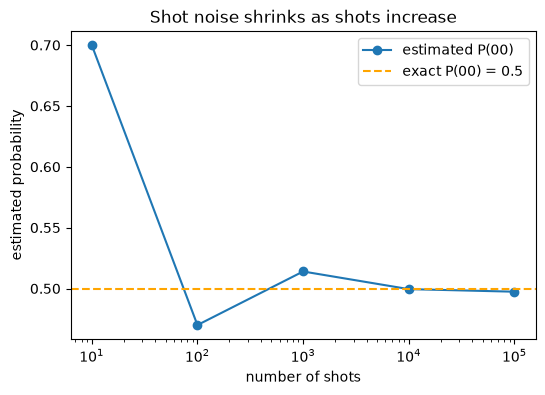

In [25]:
%matplotlib inline
import matplotlib.pyplot as plt

shot_counts = [10, 100, 1000, 10000, 100000]
estimated_p00 = []
for n in shot_counts:
    outcomes = rng.choice(len(bell), size=n, p=probs)
    estimated_p00.append(np.mean(outcomes == 0))  # fraction that landed on |00>

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(shot_counts, estimated_p00, marker="o", label="estimated P(00)")
ax.axhline(0.5, color="orange", linestyle="--", label="exact P(00) = 0.5")
ax.set_xscale("log")
ax.set_xlabel("number of shots")
ax.set_ylabel("estimated probability")
ax.set_title("Shot noise shrinks as shots increase")
ax.legend()
plt.show()

### 5.3 Observables and expectation values

A **physical observable** (something you could in principle measure — energy, spin along an axis, etc.) is represented by a Hermitian matrix $O$. Its **expectation value** in state $|\psi\rangle$ — the average result you'd get over many measurements — is

$$
\langle O \rangle_\psi = \langle \psi | O | \psi \rangle.
$$

The Pauli matrices $X, Y, Z$ are themselves observables (each has eigenvalues $\pm 1$), and products like $Z \otimes Z$ (built with `np.kron`) are the multi-qubit observables you'll use constantly:

In [26]:
ZZ = np.kron(Z, Z)

exp_val_bell = np.vdot(bell, ZZ @ bell).real
print("<Z⊗Z> for the Bell state:", exp_val_bell)

<Z⊗Z> for the Bell state: 0.9999999999999998


`<Z⊗Z> = 1` for the Bell state makes sense given what we saw in 5.1: every measurement outcome is `00` or `11` — the two qubits' $Z$-eigenvalues are always equal, so their product is always $+1$. Contrast this with a product state:

In [27]:
plus_zero = np.kron(plus, zero)   # |+>|0>, not entangled
exp_val_product = np.vdot(plus_zero, ZZ @ plus_zero).real
print("<Z⊗Z> for |+>|0>:", exp_val_product)

<Z⊗Z> for |+>|0>: -2.2371143170757382e-17


We take `.real` because for a Hermitian observable and a valid state, $\langle\psi|O|\psi\rangle$ is *mathematically guaranteed* to be real (even though NumPy always returns a complex number) — any nonzero imaginary part in your own code is a bug, not physics.

**Exercise:** compute $\langle X \otimes X \rangle$ for the Bell state `bell`, and separately for `psi_minus` from the section 2 exercise. (You should find they have opposite signs — this pair of observables, $Z\otimes Z$ and $X \otimes X$, is exactly what's used in tests of Bell inequalities, which we'll gesture at again in section 10.)

In [28]:
XX = np.kron(X, X)

exp_XX_bell = np.vdot(bell, XX @ bell).real
exp_XX_psi_minus = np.vdot(psi_minus, XX @ psi_minus).real

print("<X⊗X> for Bell state:  ", exp_XX_bell)
print("<X⊗X> for psi_minus:   ", exp_XX_psi_minus)

<X⊗X> for Bell state:   0.9999999999999998
<X⊗X> for psi_minus:    -0.9999999999999998


---

## 6. Enter Qiskit

Everything above — states as vectors, gates as unitary matrices, circuits as products of matrices, measurement as sampling — **is** quantum computing. Qiskit doesn't add new physics; it gives you a much more convenient, less error-prone, and much more scalable way to build and run the same objects, and it's the SDK the IBM Quantum ecosystem (and much of the field) has standardised on.

**What Qiskit actually is:** an open-source Python SDK, structured (as of the current 2.x releases) as a small, focused core package plus a family of add-ons:

- **`qiskit`** (the core package) gives you `QuantumCircuit` for building circuits, `qiskit.quantum_info` for exact-state tools like `Statevector`, `Operator`, and `SparsePauliOp`, and `qiskit.primitives` for two built-in *local, exact* simulators: `StatevectorSampler` and `StatevectorEstimator` — no extra install required.
- **`qiskit-aer`** is IBM's high-performance simulator package. It provides `AerSimulator`, a much faster and more configurable simulator (still classical!) that scales to more qubits and can model hardware noise — plus its own `SamplerV2`/`EstimatorV2` that speak the same interface as the built-in ones.
- Beyond what we touch today, Qiskit also has a **transpiler** (`qiskit.transpile`, used briefly in section 8) that rewrites circuits into the specific gate set and qubit connectivity a target backend supports, and a `qiskit-ibm-runtime` package for submitting jobs to real IBM Quantum hardware.

**For this school, we only ever use simulators**, either `qiskit.primitives.StatevectorSampler`/`StatevectorEstimator` (exact, always available, best for small circuits and teaching) or `qiskit_aer.AerSimulator`/`qiskit_aer.primitives.SamplerV2`/`EstimatorV2` (faster, more features, still purely classical). Nothing in this notebook talks to real quantum hardware, and you don't need an IBM Quantum account for any of it. Both `qiskit` and `qiskit-aer` were already installed in your `saqutischool` environment by the pre-school setup guide (`pip install qiskit qiskit-aer pylatexenc`) — if `import qiskit` fails below, that's the thing to check first.

In [29]:
import qiskit
import qiskit_aer

print("Qiskit version:     ", qiskit.__version__)
print("Qiskit Aer version: ", qiskit_aer.__version__)

Qiskit version:      2.5.2
Qiskit Aer version:  0.17.2


---

## 7. Qiskit fundamentals: `QuantumCircuit`, `Statevector`, `Operator`

### 7.1 Building a circuit

`QuantumCircuit(n)` creates an empty circuit on `n` qubits. Gates are added as method calls, in the order they should be applied — reading top to bottom is reading the circuit left to right:

In [30]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)
qc.h(0)      # Hadamard on qubit 0
qc.cx(0, 1)  # CNOT, control=0, target=1

qc.draw()

┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

`qc.draw()` defaults to a plain-text diagram, which needs nothing beyond Qiskit itself. If you'd like the nicer Matplotlib-rendered version used later in this notebook's images, `qc.draw(output="mpl")` works too; it needs the `pylatexenc` package, which the pre-school setup guide installs. If you get a `MissingOptionalLibraryError` mentioning `pylatexenc`, run `pip install pylatexenc` inside your activated `saqutischool` environment and restart the kernel.

Compare this directly to section 4.2: `qc.h(0)` then `qc.cx(0, 1)` is *exactly* the two-line circuit we built there by hand as `apply_1q_gate(H, 0, 2) @ psi0` followed by `CNOT @ psi1` — Qiskit is just tracking the sequence of gates symbolically instead of you multiplying matrices yourself.

### 7.2 `Statevector`: getting the exact state out

`Statevector.from_instruction` runs a circuit (assuming it starts in $|0\ldots0\rangle$ and contains no measurements) and gives you back the exact final state vector — precisely the object we were computing by hand all notebook:

In [31]:
from qiskit.quantum_info import Statevector

sv = Statevector.from_instruction(qc)
print(sv)
print("probabilities:", sv.probabilities_dict())

Statevector([0.7071+0.j, 0.    +0.j, 0.    +0.j, 0.7071+0.j],
            dims=(2, 2))
probabilities: {np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}


### 7.3 ⚠️ Qubit ordering: Qiskit is little-endian

Here is the gotcha we flagged in section 2.2. Compare applying $X$ to *qubit 0 only*, by hand and in Qiskit:

In [32]:
qc_x0 = QuantumCircuit(2)
qc_x0.x(0)
print("Qiskit's state after X on qubit 0:", Statevector.from_instruction(qc_x0).probabilities_dict())

manual_x0 = apply_1q_gate(X, 0, 2) @ np.kron(zero, zero)
print("Our manual state after X on qubit 0:", {format(i, "02b"): float(abs(a)**2) for i, a in enumerate(manual_x0) if abs(a) > 1e-9})

Qiskit's state after X on qubit 0: {np.str_('01'): np.float64(1.0)}
Our manual state after X on qubit 0: {'10': 1.0}


Qiskit reports `{'01': 1.0}`, while our by-hand convention gives `{'10': 1.0}`. **Neither is wrong** — they're two different, self-consistent conventions for which end of the bitstring corresponds to qubit 0:

- **Our convention (this notebook, sections 1–5):** "physics textbook" ordering — qubit 0 is the **leftmost** character in the ket, and multi-qubit states are built as `np.kron(q0, q1, ..., qn-1)`.
- **Qiskit's convention:** "little-endian" ordering — qubit 0 is the **rightmost** character in the ket (like the least-significant bit of a binary number), matching `np.kron(q_{n-1}, ..., q1, q0)`.

Practical takeaway: when you read a Qiskit bitstring like `'01'`, the *rightmost* digit is qubit 0. As long as you're consistent within whichever convention you're using, physics is unaffected — but comparing a hand-built statevector to a Qiskit one requires reversing the qubit order first. `Statevector` has a method for exactly this:

In [33]:
sv_x0 = Statevector.from_instruction(qc_x0)
print("Qiskit order:", sv_x0.probabilities_dict())
print("reversed to match our convention:", sv_x0.reverse_qargs().probabilities_dict())

Qiskit order: {np.str_('01'): np.float64(1.0)}
reversed to match our convention: {np.str_('10'): np.float64(1.0)}


### 7.4 `Operator`: reading off the unitary matrix of a circuit

`Operator` converts any circuit with no measurements into its full unitary matrix — useful for directly checking a circuit against a matrix you derived by hand:

In [34]:
from qiskit.quantum_info import Operator

qc_h = QuantumCircuit(1)
qc_h.h(0)
print("Qiskit's H matrix:\n", Operator(qc_h).data)
print("matches our H?", np.allclose(Operator(qc_h).data, H))

qc_cx = QuantumCircuit(2)
qc_cx.cx(0, 1)
print("\nQiskit's CNOT matrix (little-endian!):\n", Operator(qc_cx).data)

Qiskit's H matrix:
 [[ 0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071+0.j]]
matches our H? True

Qiskit's CNOT matrix (little-endian!):
 [[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]]


Notice Qiskit's `CNOT` matrix looks different from our hand-built `CNOT` in section 3.2 — same gate, same physics, just written in the little-endian basis ordering.

**Exercise:** build the Bell circuit in Qiskit (`h(0)` then `cx(0, 1)`), get its `Statevector`, reverse it to our convention with `.reverse_qargs()`, and confirm it matches the `bell` array from section 2.3. Then build the 3-qubit GHZ circuit in Qiskit and draw it.

In [35]:
qc_bell = QuantumCircuit(2)
qc_bell.h(0)
qc_bell.cx(0, 1)

sv_bell = Statevector.from_instruction(qc_bell).reverse_qargs()
print("Qiskit Bell state (our convention):", np.asarray(sv_bell))
print("matches hand-built bell?", np.allclose(np.asarray(sv_bell), bell))

qc_ghz = QuantumCircuit(3)
qc_ghz.h(0)
qc_ghz.cx(0, 1)
qc_ghz.cx(1, 2)
qc_ghz.draw()

Qiskit Bell state (our convention): [0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]
matches hand-built bell? True


┌───┐          
q_0: ┤ H ├──■───────
     └───┘┌─┴─┐     
q_1: ─────┤ X ├──■──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘

---

## 8. Measurement in Qiskit: shots and counts

### 8.1 Adding measurements to a circuit

`measure_all()` appends a computational-basis measurement of every qubit, plus a classical register to store the results:

In [36]:
qc_bell_meas = qc_bell.copy()
qc_bell_meas.measure_all()
qc_bell_meas.draw()

┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        └───┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├─░──╫─┤M├
             └───┘ ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1

### 8.2 `StatevectorSampler`: exact, local, no extra install

The `Sampler` primitive runs a circuit some number of `shots` and returns **counts** — exactly the object we built by hand with `np.random.choice` in section 5.2, except Qiskit is doing the sampling internally:

In [37]:
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()
job = sampler.run([qc_bell_meas], shots=1000)
result = job.result()

counts = result[0].data.meas.get_counts()
print("counts:", counts)

counts: {'11': 501, '00': 499}


A couple of API details worth knowing: `sampler.run` takes a *list* of circuits (so you can batch several jobs in one call), and the result of each one is accessed through `.data.<register_name>` — `measure_all()` names the classical register `meas` by default, which is why it's `result[0].data.meas`.

### 8.3 `AerSimulator`: the faster, more scalable simulator

`qiskit-aer`'s `AerSimulator` follows the classic "backend `.run()`" pattern rather than the primitives interface, and needs your circuit **transpiled** first (compiled into the gate set the simulator backend expects — for `AerSimulator` this mostly matters once you start adding noise models, but it's good habit to always transpile before running):

In [38]:
from qiskit import transpile
from qiskit_aer import AerSimulator

sim = AerSimulator()
tqc = transpile(qc_bell_meas, sim)

job = sim.run(tqc, shots=1000)
result = job.result()
counts_aer = result.get_counts()
print("AerSimulator counts:", counts_aer)

AerSimulator counts: {'11': 516, '00': 484}


You can also use Aer's own primitives (`qiskit_aer.primitives.SamplerV2`), which give you the exact same `.data.meas.get_counts()` interface as `StatevectorSampler` above but run on the Aer backend — handy when you outgrow what the built-in statevector simulator can handle:

In [39]:
from qiskit_aer.primitives import SamplerV2

sampler_aer = SamplerV2()
job = sampler_aer.run([qc_bell_meas], shots=1000)
counts_aer_v2 = job.result()[0].data.meas.get_counts()
print("Aer SamplerV2 counts:", counts_aer_v2)

Aer SamplerV2 counts: {'00': 492, '11': 508}


### 8.4 Visualising counts

`qiskit.visualization.plot_histogram` is the standard way to plot a counts dictionary:

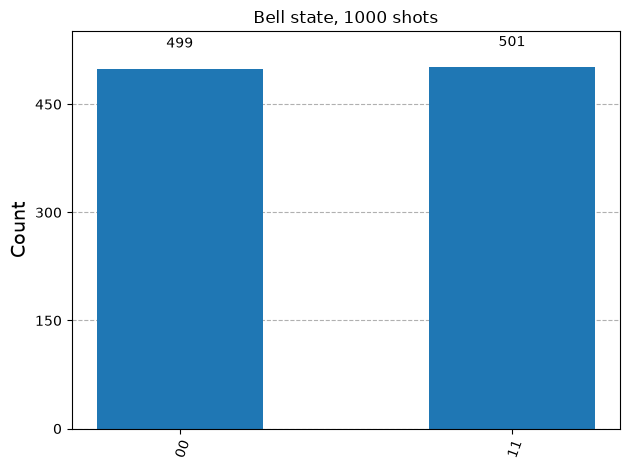

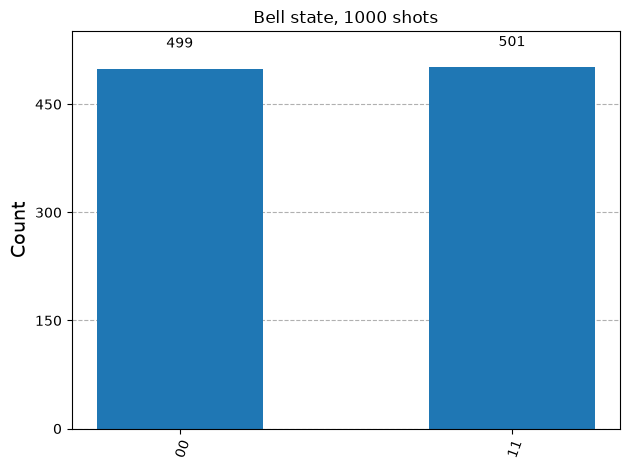

In [40]:
from qiskit.visualization import plot_histogram

plot_histogram(counts, title="Bell state, 1000 shots")

**Exercise:** build the 3-qubit GHZ circuit from section 7's exercise, add `measure_all()`, run it with `StatevectorSampler` at 2000 shots, and plot the resulting counts. You should see (up to statistical noise) only `'000'` and `'111'` — no other bitstring should appear, for the same reason as in section 4.4's manual calculation.

{'000': 992, '111': 1008}


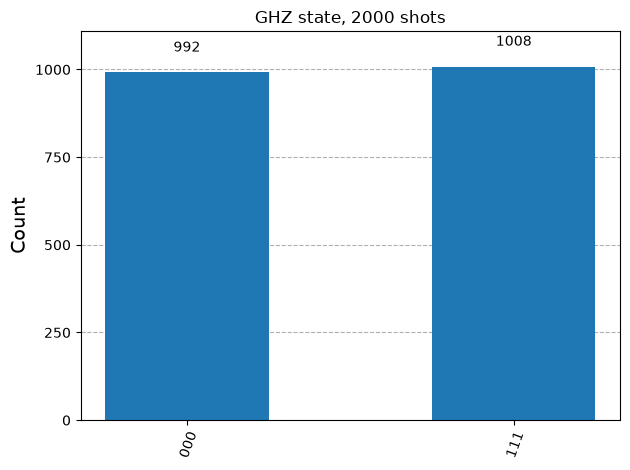

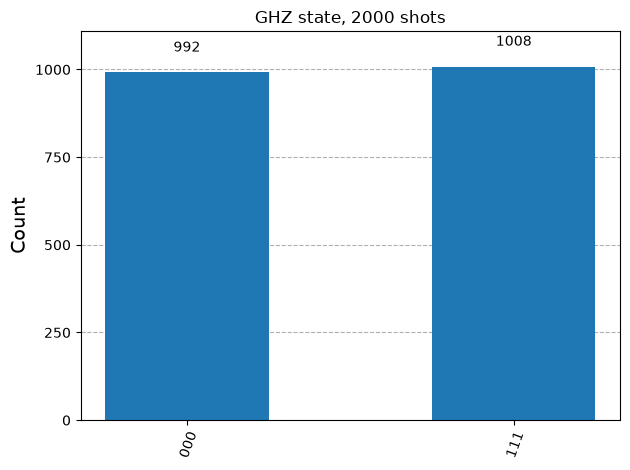

In [41]:
qc_ghz_meas = qc_ghz.copy()
qc_ghz_meas.measure_all()

sampler = StatevectorSampler()
counts_ghz = sampler.run([qc_ghz_meas], shots=2000).result()[0].data.meas.get_counts()
print(counts_ghz)
plot_histogram(counts_ghz, title="GHZ state, 2000 shots")

---

## 9. Observables in Qiskit: `SparsePauliOp` and the `Estimator`

### 9.1 Building observables with `SparsePauliOp`

Rather than writing out full matrices with `np.kron` as we did in section 5.3, Qiskit lets you specify multi-qubit Pauli observables directly by their Pauli string, via `SparsePauliOp`:

In [42]:
from qiskit.quantum_info import SparsePauliOp

zz_observable = SparsePauliOp(["ZZ"])
print(zz_observable)
print("as a matrix:\n", zz_observable.to_matrix())

SparsePauliOp(['ZZ'],
              coeffs=[1.+0.j])
as a matrix:
 [[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  1.+0.j]]


`SparsePauliOp` also lets you build **weighted sums** of Pauli strings in one object — e.g. `SparsePauliOp(["ZZ", "XX"], coeffs=[1, -1])` represents $Z\otimes Z - X \otimes X$ — which is exactly the kind of object you need to represent a physical Hamiltonian, though we won't need that generality today.

### 9.2 `StatevectorEstimator`: exact expectation values

The `Estimator` primitive computes $\langle\psi|O|\psi\rangle$ directly — the circuit must **not** contain measurements (measurement destroys the state we need to compute an exact expectation value from):

In [43]:
from qiskit.primitives import StatevectorEstimator

estimator = StatevectorEstimator()
job = estimator.run([(qc_bell, zz_observable)])
result = job.result()

print("<Z⊗Z> for the Bell circuit:", result[0].data.evs)

<Z⊗Z> for the Bell circuit: 0.9999999999999998


Compare this to `exp_val_bell` from section 5.3 — same number, computed the "Qiskit way" instead of by hand with `np.vdot`. (Bit-ordering is a non-issue here: `Z⊗Z` and `X⊗X` are symmetric under swapping the two qubits, so the little-endian-vs-textbook convention doesn't change the answer for these particular observables — worth keeping in mind for less symmetric ones, though.)

### 9.3 From exact expectation values to shot-based estimates

On a real experiment (or when you deliberately want to emulate shot noise) you don't get the exact expectation value — you estimate it from a finite number of measurements, and the estimate comes with some uncertainty. `StatevectorEstimator` lets you request a target `precision` (roughly, the standard error you're willing to accept) instead of an exact answer:

In [44]:
job_noisy = estimator.run([(qc_bell, zz_observable)], precision=0.05)
result_noisy = job_noisy.result()

print("estimated <Z⊗Z>:", result_noisy[0].data.evs)
print("standard error:  ", result_noisy[0].data.stds)

estimated <Z⊗Z>: 1.0057464534551523
standard error:   0.0


Run that cell a few times — the estimate jitters around 1.0 each time (it's simulating shot noise), while the noise-free version in 9.2 gives exactly the same number every time. `qiskit_aer.primitives.EstimatorV2` behaves the same way and is the version to reach for once your circuits outgrow the built-in statevector simulator:

In [45]:
from qiskit_aer.primitives import EstimatorV2

estimator_aer = EstimatorV2()
result_aer = estimator_aer.run([(qc_bell, zz_observable)]).result()
print("Aer EstimatorV2 <Z⊗Z>:", result_aer[0].data.evs)

Aer EstimatorV2 <Z⊗Z>: 1.0


**Exercise:** using `StatevectorEstimator`, compute $\langle X \otimes X\rangle$ for the Bell circuit `qc_bell` and compare it to `exp_XX_bell` from the section 5.3 exercise. Then compute both $\langle Z\otimes Z\rangle$ and $\langle X \otimes X\rangle$ for the GHZ circuit `qc_ghz` in one call, by passing a list of `(circuit, observable)` pairs.

In [46]:
xx_observable = SparsePauliOp(["XX"])

result_xx = estimator.run([(qc_bell, xx_observable)]).result()
print("<X⊗X> for Bell circuit (Qiskit):", result_xx[0].data.evs)
print("matches hand-computed value?", np.isclose(result_xx[0].data.evs, exp_XX_bell))

result_ghz = estimator.run([
    (qc_ghz, SparsePauliOp(["ZZI"])),
    (qc_ghz, SparsePauliOp(["XXI"])),
]).result()
print("<Z⊗Z⊗I> for GHZ:", result_ghz[0].data.evs)
print("<X⊗X⊗I> for GHZ:", result_ghz[1].data.evs)

<X⊗X> for Bell circuit (Qiskit): 0.9999999999999998
matches hand-computed value? True
<Z⊗Z⊗I> for GHZ: 0.9999999999999998
<X⊗X⊗I> for GHZ: 0.0


---

## 10. Putting it together

**Capstone exercise:** build a circuit that prepares $R_y(\theta)|0\rangle$ on qubit 0 (tensored with $|0\rangle$ on qubit 1), entangles the two qubits with a `cx(0, 1)`, and then:

1. Use `StatevectorEstimator` to compute the **exact** value of $\langle Z \otimes Z \rangle$ as a function of $\theta$, for say 30 values of $\theta$ between $0$ and $2\pi$, and plot it.
2. On the same axes, plot **shot-based estimates** of the same quantity (using `precision=0.1`, or equivalently running `StatevectorSampler` and computing the expectation value yourself from the counts) to see the shot noise scattered around the exact curve.

This ties together nearly everything from the notebook: `Ry` as a matrix exponential (section 3), building a circuit (sections 4 and 7), `SparsePauliOp` observables and the `Estimator` (section 9), and the shots-vs-exact distinction that runs through sections 5 and 8–9.

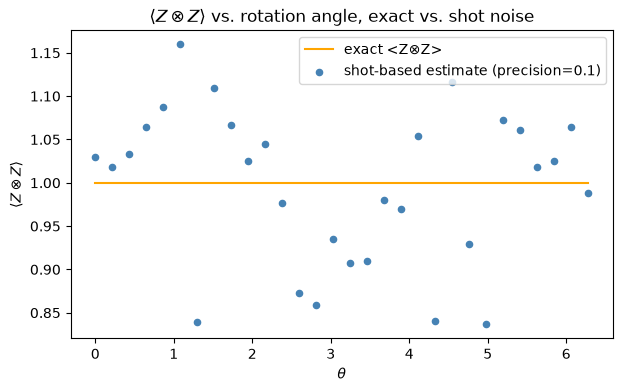

In [47]:
thetas = np.linspace(0, 2 * np.pi, 30)
exact_vals = []
noisy_vals = []

zz = SparsePauliOp(["ZZ"])

for theta in thetas:
    qc = QuantumCircuit(2)
    qc.ry(theta, 0)
    qc.cx(0, 1)

    exact = estimator.run([(qc, zz)]).result()[0].data.evs
    noisy = estimator.run([(qc, zz)], precision=0.1).result()[0].data.evs

    exact_vals.append(float(exact))
    noisy_vals.append(float(noisy))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thetas, exact_vals, color="orange", label="exact <Z⊗Z>")
ax.scatter(thetas, noisy_vals, color="steelblue", s=20, label="shot-based estimate (precision=0.1)")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\langle Z \otimes Z \rangle$")
ax.set_title(r"$\langle Z \otimes Z \rangle$ vs. rotation angle, exact vs. shot noise")
ax.legend()
plt.show()

You should see a smooth $\cos(\theta)$-like curve from the exact estimator, with the shot-based points scattered around it — closer to the curve for smaller `precision` values (more effective shots), further off for larger ones. This is the practical shape of almost every near-term quantum experiment: an exact quantity you're trying to learn, and a finite-shots estimate of it with quantifiable statistical error.

---

## 11. Wrap-up

**What we covered:**

- A quantum state is a normalised complex vector; multi-qubit states live in a tensor-product space built with `np.kron`.
- Evolution is multiplication by a unitary matrix; `scipy.linalg.expm` builds unitaries from Hermitian generators.
- A circuit is just a sequence of unitary matrices applied to a state, one per "layer."
- Measurement is sampling from a probability distribution given by the Born rule ($p_i = |\psi_i|^2$); repeated measurements ("shots") give "counts," whose frequencies converge to the exact probabilities as shots grow.
- An observable is a Hermitian matrix; its expectation value is $\langle\psi|O|\psi\rangle$, computable exactly or estimated from shots.
- Qiskit's `QuantumCircuit`, `Statevector`, `Operator`, `SparsePauliOp`, `Sampler`, and `Estimator` are convenient, standard implementations of exactly these ideas — and everything we ran today was on a classical simulator (`StatevectorSampler`/`StatevectorEstimator` or `qiskit-aer`'s `AerSimulator`), never real hardware.

**Common pitfalls to watch for:**

- Forgetting `dtype=complex` when building NumPy arrays for quantum states — real-valued arrays will silently truncate imaginary parts (e.g. from `Y` or from `expm` results) rather than raising an error.
- Mixing up Qiskit's little-endian bitstring convention with the "qubit 0 leftmost" convention used in most textbooks and in the first half of this notebook — section 7.3 has the fix (`.reverse_qargs()`), and it's worth bookmarking.
- Passing a circuit **with** measurements to an `Estimator`, or **without** measurements to a `Sampler` — each primitive requires the opposite of what you'd expect from the other.
- Forgetting `transpile()` before `AerSimulator.run()` — it will often still work for simple circuits with no noise model, but get in the habit early since it becomes mandatory once real device constraints (noise, connectivity) are in play.

**Cheat sheet: doing it by hand vs. doing it in Qiskit**

| Concept | By hand (NumPy/SciPy) | Qiskit |
|---|---|---|
| Qubit state | `np.array([a, b], dtype=complex)` | `Statevector.from_instruction(qc)` |
| Multi-qubit state | `np.kron(q0, q1, ...)` | built implicitly by `QuantumCircuit` |
| Gate as a unitary | hand-written matrix, or `expm(-1j * theta/2 * H)` | `qc.h(0)`, `qc.ry(theta, 0)`, `qc.cx(0,1)`, ... |
| Reading off a circuit's matrix | multiply gate matrices together | `Operator(qc).data` |
| Measurement probabilities | `np.abs(psi)**2` | `Statevector(...).probabilities_dict()` |
| Shots & counts | `rng.choice(..., p=probs)` + tally | `Sampler().run([qc], shots=n)` → `.data.meas.get_counts()` |
| Observable | Hermitian `np.array` (e.g. `np.kron(Z, Z)`) | `SparsePauliOp(["ZZ"])` |
| Expectation value | `np.vdot(psi, O @ psi).real` | `Estimator().run([(qc, obs)])` → `.data.evs` |

Next session builds on exactly these Qiskit tools to run larger, more structured simulations.